
# Visualizing Relationships Between Categorical Features

This notebook completes the practice activity on exploring the relationship between **passenger class (`Pclass`)** and **survival (`Survived`)** in the Titanic dataset.

## Objectives
1. Read `titanic_passengers.csv` into a DataFrame.
2. Create a cross-tabulation between passenger class and survival.
3. Calculate the relative frequency for each category.
4. Plot a stacked bar plot of passenger class and survival.
5. Calculate the percent of individuals in each passenger class who perished and survived.
6. Calculate the percent of individuals who survived and perished who were from each passenger class.


In [2]:

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


## 1. Read in the dataset

In [3]:

# Try common locations for the Titanic dataset
possible_paths = [
    Path('titanic_passengers.csv'),
    Path('./titanic_passengers.csv'),
    Path('assets/titanic_passengers.csv'),
    Path('./assets/titanic_passengers.csv')
]

for path in possible_paths:
    if path.exists():
        df = pd.read_csv(path)
        print(f"Loaded dataset from: {path}")
        break
else:
    raise FileNotFoundError(
        "Could not find 'titanic_passengers.csv'. Place it in the same folder as this notebook or in an 'assets' folder."
    )

# Preview the data
df.head()


Loaded dataset from: assets\titanic_passengers.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Cross-tabulation between passenger class and survival

In [4]:

class_survival_counts = pd.crosstab(df['Pclass'], df['Survived'])
class_survival_counts


Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119



The table above shows the **number of passengers** in each category of:
- **Passenger class (`Pclass`)**
- **Survival (`Survived`)**, where `0 = did not survive` and `1 = survived`


## 3. Relative frequency of passenger class and survival

In [5]:

class_survival_relative = pd.crosstab(df['Pclass'], df['Survived'], normalize=True)
class_survival_relative


Survived,0,1
Pclass,,
1,0.089787,0.152637
2,0.108866,0.097643
3,0.417508,0.133558



The relative frequency table above shows the **proportion of the full dataset** in each passenger class and survival combination.


## 4. Stacked bar plot of frequencies

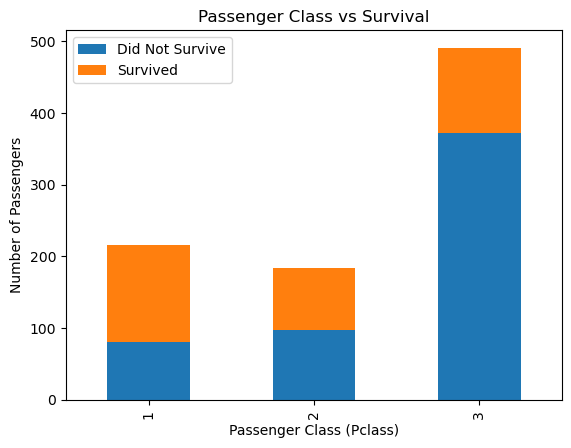

In [6]:

class_survival_counts.plot(kind='bar', stacked=True)
plt.title('Passenger Class vs Survival')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Number of Passengers')
plt.legend(['Did Not Survive', 'Survived'])
plt.show()



### Answer
The **3rd class passengers** were the **least likely to survive**.


## 5. Percent of individuals in each passenger class who perished and survived

In [7]:

# Conditional proportions within each passenger class
class_based_percent = pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100
class_based_percent


Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253



This table shows, **within each passenger class**, the percent who:
- **Perished** (`Survived = 0`)
- **Survived** (`Survived = 1`)


## 6. Percent of individuals who survived and perished who were from each passenger class

In [8]:

# Conditional proportions within each survival category
survival_based_percent = pd.crosstab(df['Pclass'], df['Survived'], normalize='columns') * 100
survival_based_percent


Survived,0,1
Pclass,,
1,14.571949,39.766082
2,17.668488,25.438596
3,67.759563,34.795322



This table shows, **within each survival outcome**, the percent of passengers who came from each passenger class.


## Summary


This notebook completed all required objectives for the assignment:
- Imported the dataset into a DataFrame
- Created a cross-tabulation of `Pclass` and `Survived`
- Calculated relative frequencies
- Visualized the counts with a stacked bar plot
- Calculated conditional proportions by passenger class
- Calculated conditional proportions by survival status

Based on the visualization and proportions, **3rd class passengers were the least likely to survive**.
